In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [17]:
headers = ["unix_ms","frame","node_idx","x","y"]

# files containing data from polygon expriments
# mds-log-polygon-triangle.csv
# mds-log-polygon-square.csv
# mds-log-polygon-library.csv
file = "mds-log-polygon-library.csv"
csv = np.genfromtxt(f"../results/{file}", delimiter=",", dtype=float, skip_header=1)

## data = {"frame": frame_number, "x": [x1, x2, ..], "y": [y1, y2, ..]}

data = []
current_frame = None
data_point = {}
for idx, record in enumerate(csv):
    if record[1] != current_frame:
        if idx != 0:
            data.append(data_point)
        current_frame = record[1]
        data_point = { "frame": record[1], "x": [record[-2]], "y": [record[-1]] }
    else:
        data_point["x"].append(record[-2])
        data_point["y"].append(record[-1])
if data_point is not None:
    data.append(data_point)
data[:2]

[{'frame': np.float64(0.0),
  'x': [np.float64(0.0),
   np.float64(-6.647568),
   np.float64(-4.368851),
   np.float64(-1.552383),
   np.float64(-10.393509),
   np.float64(-7.179382),
   np.float64(-12.10701),
   np.float64(-4.023331),
   np.float64(-1.095322)],
  'y': [np.float64(0.0),
   np.float64(-7.529602),
   np.float64(1.388992),
   np.float64(5.537048),
   np.float64(0.963867),
   np.float64(-2.849686),
   np.float64(5.171921),
   np.float64(9.03067),
   np.float64(-4.01268)]},
 {'frame': np.float64(1.0),
  'x': [np.float64(0.0),
   np.float64(-6.635757),
   np.float64(-4.35466),
   np.float64(-1.523926),
   np.float64(-10.379028),
   np.float64(-7.171432),
   np.float64(-12.099976),
   np.float64(-4.024338),
   np.float64(-1.084152)],
  'y': [np.float64(0.0),
   np.float64(-7.521118),
   np.float64(1.402435),
   np.float64(5.547104),
   np.float64(0.977402),
   np.float64(-2.840622),
   np.float64(5.175568),
   np.float64(9.03717),
   np.float64(-4.006546)]}]

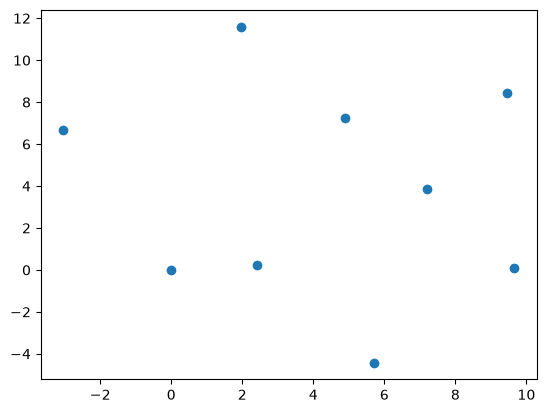

In [18]:
## last position

last_mds = data[-1]
plt.scatter(last_mds["x"], last_mds["y"])

In [19]:
node_count = len(data[0]["x"])

sum_pozx = [0 for _ in range(node_count)]
sum_pozy = [0 for _ in range(node_count)]

for dp in data:
    for i in range(node_count):
        sum_pozx[i] += dp["x"][i]
        sum_pozy[i] += dp["y"][i]

x_avg = [x / 9 for x in sum_pozx]
y_avg = [y / 9 for y in sum_pozy]

x_avg

[np.float64(0.0),
 np.float64(201.6144998888889),
 np.float64(309.2547778888892),
 np.float64(414.8477982222223),
 np.float64(110.54334899999996),
 np.float64(31.57852566666667),
 np.float64(-238.0797844444443),
 np.float64(75.49390022222214),
 np.float64(440.14822488888893)]

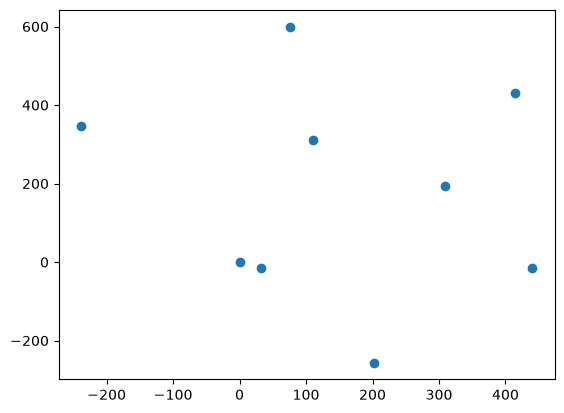

In [20]:
plt.scatter(x_avg, y_avg)